# ⚽ Notebook Final: Predicción de Resultados del Fútbol Uruguayo
### **Aprendizaje Automático — Facultad de Ingeniería (UdelaR)**

Este notebook consolida y unifica todo el trabajo experimental desarrollado para la predicción de resultados de partidos de fútbol uruguayo:
1. **Carga de Datos, EDA y Preprocesamiento Definitorio** (Partición temporal y pipeline de extracción de características).
2. **Modelo Heurístico de Línea Base** (Clasificador basado en el historial de victorias de los últimos 10 años).
3. **Árboles de Decisión y Random Forest** (Árbol propio con `min_info_gain` y `max_depth`, curvas de error, diagnóstico y control de sobreajuste, y `RandomForestClassifier`).
4. **Clasificadores Naive Bayes** (Naive Bayes propio con suavizado $m$-estimate e integración completa del pipeline, y `CategoricalNB` de scikit-learn con `OrdinalEncoder`).
5. **Comparativa Global de Modelos y Conclusiones Finales**.
6. **Demostración de Clasificación de Instancias Específicas** (Predicción detallada de partidos individuales per Entregable 2).


## 1. Importación de Librerías y Configuración General

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Asegurar que el directorio raíz del proyecto esté en sys.path independientemente de dónde se ejecute
root_dir = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if root_dir not in sys.path:
    sys.path.append(root_dir)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline

# Módulos modularizados en src/
from src.pipeline import get_train_test_data, preprocessing_pipeline
from src.baseline import ClasificadorBase10Anios
from src.tree_models import DecisionTreeClassifierCustom
from src.naive_bayes import NaiveBayesPropio
from src.metrics import evaluar_modelo, graficar_matriz_confusion, graficar_metrica_vs_hiperparametro

CLASES = ['L', 'E', 'V']  # Orden fijo para matrices de confusión
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
%matplotlib inline

print("Entorno configurado e importaciones cargadas correctamente.")

Entorno configurado e importaciones cargadas correctamente.


## 2. Carga de Datos, EDA y Preprocesamiento Definitorio

Al trabajar con series temporales (partidos de fútbol desde 1932 hasta 2025), la partición de los datos debe respetar estrictamente la línea cronológica para evitar la fuga de información (*data leakage*):
* **Eliminación de duplicados:** Se eliminan las filas exactas duplicadas.
* **Tratamiento del Target (`ganador`):** 'L' si gana el local, 'V' si gana el visitante, 'E' en caso de empate (`gh == ga`). Los partidos definidos por penales ('P') se tratan como empates ('E') al quedar igualados en el tiempo reglamentario.
* **Conjunto de Entrenamiento:** Partidos jugados hasta el año 2023 inclusive.
* **Conjunto de Evaluación (Test):** Partidos jugados exclusivamente durante 2024 y 2025.
* **Pipeline de Preprocesamiento (`preprocessing_pipeline`):** Aplica la limpieza de columnas irrelevantes, `TeamFormTransformer` (tasa de victoria reciente en 10 años: `home_form` y `away_form`), extracción de año/mes, y One-Hot Encoding de equipos.

In [2]:
# Carga de datos y partición temporal única (resolviendo ruta según el directorio de ejecución)
data_path = '../data/raw/futbol_uruguayo.csv' if os.path.exists('../data/raw/futbol_uruguayo.csv') else 'data/raw/futbol_uruguayo.csv'
X_train, y_train, X_test, y_test = get_train_test_data(filepath=data_path)

print(f"Partidos de entrenamiento (hasta 2023): {len(X_train)}")
print(f"Partidos de evaluación (2024-2025): {len(X_test)}")
print("\nDistribución de clases en el conjunto de entrenamiento:")
print(y_train.value_counts(normalize=True).round(3))

# Procesamiento con el pipeline unificado
X_train_processed = preprocessing_pipeline.fit_transform(X_train, y_train)
X_test_processed = preprocessing_pipeline.transform(X_test)
nombres_columnas = preprocessing_pipeline.named_steps['encoder'].get_feature_names_out()

X_train_visible = pd.DataFrame(X_train_processed, columns=nombres_columnas)
X_test_visible = pd.DataFrame(X_test_processed, columns=nombres_columnas)

print(f"\nAtributos procesados para modelos matriciales ({X_train_visible.shape[1]} columnas):")
display(X_train_visible.head())

Partidos de entrenamiento (hasta 2023): 14734
Partidos de evaluación (2024-2025): 472

Distribución de clases en el conjunto de entrenamiento:
ganador
L    0.445
V    0.281
E    0.274
Name: proportion, dtype: float64

Atributos procesados para modelos matriciales (80 columnas):


,teams_encoder__home_Albion,teams_encoder__home_Bella Vista,teams_encoder__home_Boston River,teams_encoder__home_CA Basanez,teams_encoder__home_CA Cerro,teams_encoder__home_CA Fenix,teams_encoder__home_CA Juventud,teams_encoder__home_CA Penarol,teams_encoder__home_CA Progreso,teams_encoder__home_CSyd Villa Espanola,...,teams_encoder__away_Rentistas,teams_encoder__away_River Plate,teams_encoder__away_Rocha Futbol Club,teams_encoder__away_Tacuarembo Futbol Club,teams_encoder__away_Torque FC,teams_encoder__away_Villa Teresa,remainder__home_form,remainder__away_form,remainder__year,remainder__month
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.5,1932.0,3.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.5,0.5,1932.0,3.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.5,1932.0,3.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.5,1932.0,3.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.5,1932.0,3.0


## 3. Funciones de Evaluación Generales

Utilizamos funciones estandarizadas (en `src/metrics.py`) para reportar Precisión, Recall, F1 por clase, Accuracy, Macro-F1 y Graficar la Matriz de Confusión sobre el orden fijo de clases `['L', 'E', 'V']`.

## 4. Modelo de Línea Base (Baseline Classifier)

El **Clasificador Base (`ClasificadorBase10Anios`)** predice la victoria basándose en la mayor proporción de partidos ganados por cada equipo en los **últimos 10 años** anteriores a la fecha del encuentro analizado. Sirve como punto de comparación benchmark para los algoritmos avanzados.

Entrenando el Clasificador Base (10 Años)...
=== Clasificador Base (10 Años) ===
              precision    recall  f1-score   support

           L      0.502     0.632     0.559       190
           E      0.250     0.008     0.015       131
           V      0.424     0.642     0.511       151

    accuracy                          0.462       472
   macro avg      0.392     0.427     0.362       472
weighted avg      0.407     0.462     0.393       472



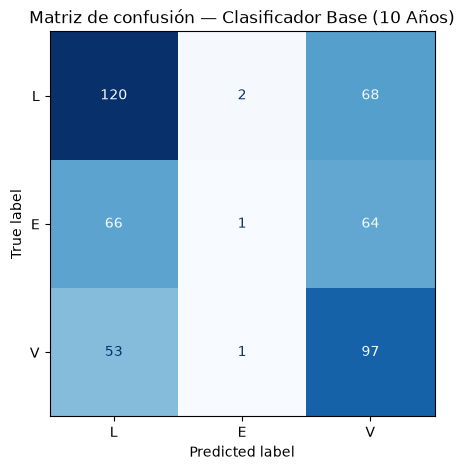

In [3]:
print("Entrenando el Clasificador Base (10 Años)...")
clf_base = ClasificadorBase10Anios()
clf_base.fit(X_train, y_train)

previsiones_base = clf_base.predict(X_test)

metricas_base = evaluar_modelo(y_test, previsiones_base, "Clasificador Base (10 Años)")
_ = graficar_matriz_confusion(y_test, previsiones_base, "Clasificador Base (10 Años)")
plt.show()

## 5. Árboles de Decisión y Random Forest (Rol 2)

En esta sección se evalúa:
1. **Prueba de humo (sanity check):** Validación del Árbol de Decisión Propio sobre un conjunto de datos de juguete.
2. **Árbol de decisión propio (`DecisionTreeClassifierCustom`):** Búsqueda del hiperparámetro `min_info_gain` (ganancia de información mínima) como único criterio de pre-poda.
3. **Diagnóstico de sobreajuste:** Análisis de causas por las cuales `min_info_gain=0.0` resulta óptimo y evaluación de hipótesis.
4. **Random Forest de scikit-learn:** Modelo de ensamble (*bagging*) para reducir la varianza.

### 5.1 Prueba de humo (sanity check) con dataset de juguete
Validamos la lógica del árbol con el dataset "Clima / Jugar Tenis". Si el árbol memoriza correctamente este dataset chico (accuracy 1.0), se confirma la corrección algorítmica de `fit()`, `predict()` y `_build_tree()`.

In [4]:
data_toy = {
    'Clima': ['Sol', 'Sol', 'Nublado', 'Lluvia', 'Lluvia', 'Lluvia', 'Nublado', 'Sol', 'Sol', 'Lluvia', 'Sol', 'Nublado', 'Nublado', 'Lluvia'],
    'Temperatura': [85, 80, 83, 70, 68, 65, 64, 72, 69, 75, 75, 72, 81, 71],
    'Viento': ['Suave', 'Fuerte', 'Suave', 'Suave', 'Suave', 'Fuerte', 'Fuerte', 'Suave', 'Suave', 'Suave', 'Fuerte', 'Fuerte', 'Suave', 'Fuerte'],
    'Resultado': ['L', 'L', 'E', 'V', 'V', 'L', 'E', 'L', 'V', 'V', 'E', 'E', 'E', 'L']
}
df_toy = pd.DataFrame(data_toy)
X_toy = df_toy.drop('Resultado', axis=1)
y_toy = df_toy['Resultado']

tree_toy = DecisionTreeClassifierCustom(min_info_gain=0.01)
tree_toy.fit(X_toy, y_toy)
preds_toy = tree_toy.predict(X_toy)

print(f"Predicciones sobre el toy dataset: {preds_toy}")
print(f"Precisión en entrenamiento (sanity check): {accuracy_score(y_toy, preds_toy):.2f}")

Predicciones sobre el toy dataset: ['L' 'L' 'E' 'V' 'V' 'L' 'E' 'L' 'V' 'V' 'E' 'E' 'E' 'L']
Precisión en entrenamiento (sanity check): 1.00


### 5.2 Búsqueda de hiperparámetros (`min_info_gain` y `max_depth`) para el Árbol Propio

La ganancia de información se define como:
$$\text{Ganancia}(S, A) = \text{Entropía}(S) - \sum_{v \in \text{valores}(A)} \frac{|S_v|}{|S|}\text{Entropía}(S_v)$$

Se utiliza `TimeSeriesSplit` (5 divisiones) y se evalúan combinaciones de `min_info_gain` y `max_depth` para encontrar el mejor equilibrio entre capacidad y control de pre-poda.


Buscando mejores hiperparámetros (min_info_gain y max_depth) para el Árbol Propio...
Mejores hiperparámetros encontrados para el Árbol Propio: {'max_depth': 12, 'min_info_gain': 0.0}
=== Árbol Propio ({'max_depth': 12, 'min_info_gain': 0.0}) ===
              precision    recall  f1-score   support

           L      0.446     0.632     0.523       190
           E      0.289     0.214     0.246       131
           V      0.472     0.331     0.389       151

    accuracy                          0.419       472
   macro avg      0.402     0.392     0.386       472
weighted avg      0.411     0.419     0.403       472



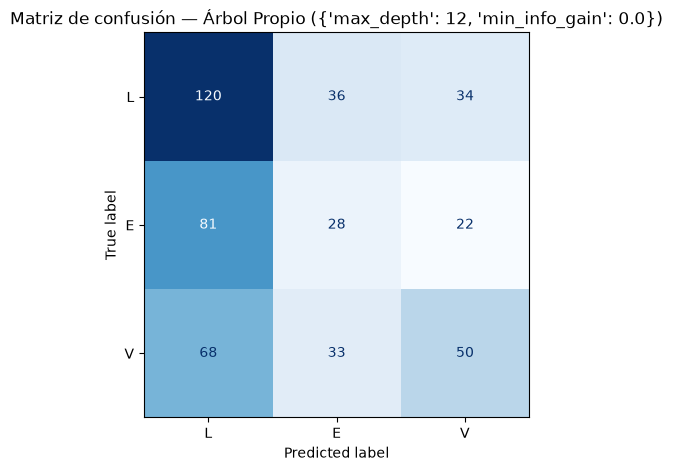

In [5]:
print("Buscando mejores hiperparámetros (min_info_gain y max_depth) para el Árbol Propio...")

tscv = TimeSeriesSplit(n_splits=5)
param_grid_arbol = {
    'min_info_gain': [0.0, 0.001, 0.01],
    'max_depth': [3, 5, 8, 12, None]
}

grid_arbol = GridSearchCV(
    estimator=DecisionTreeClassifierCustom(min_samples_split=5),
    param_grid=param_grid_arbol,
    cv=tscv,
    scoring='f1_macro',
    n_jobs=-1,
    return_train_score=True
)

grid_arbol.fit(X_train_visible, y_train)

mejores_params_arbol = grid_arbol.best_params_
mejor_ganancia = mejores_params_arbol.get('min_info_gain', 0.0)
print(f"Mejores hiperparámetros encontrados para el Árbol Propio: {mejores_params_arbol}")

arbol_mejor = grid_arbol.best_estimator_
preds_arbol = arbol_mejor.predict(X_test_visible)

metricas_arbol = evaluar_modelo(y_test, preds_arbol, f"Árbol Propio ({mejores_params_arbol})")
_ = graficar_matriz_confusion(y_test, preds_arbol, f"Árbol Propio ({mejores_params_arbol})")
plt.show()


### 5.3 Diagnóstico de Sobreajuste: ¿Por qué `min_info_gain=0.0` es óptimo?

Se evaluaron dos hipótesis:
* **Hipótesis A (Sesgo de alta cardinalidad):** El criterio ID3 puro favorece atributos con muchos valores únicos (como `home`/`away` en One-Hot).
* **Hipótesis B (Limitación del criterio de parada):** Usar únicamente `min_info_gain` (sin límite de profundidad ni mínimo de ejemplos por hoja) permite que el árbol divida hasta nodos residuales con muy pocos ejemplos.

Probamos remover los equipos en One-Hot y ampliar la grilla de `min_info_gain`:

In [6]:
mejor_ganancia = mejores_params_arbol.get('min_info_gain', 0.0) if 'mejores_params_arbol' in locals() else (getattr(arbol_mejor, 'min_info_gain', 0.0) if 'arbol_mejor' in locals() else 0.0)
acc_train_arbol = accuracy_score(y_train, arbol_mejor.predict(X_train_visible))
print(f"Accuracy en Entrenamiento (Mejor Árbol, min_info_gain={mejor_ganancia}): {acc_train_arbol:.4f}")

columnas_equipo = [c for c in X_train_visible.columns if c.startswith('teams_encoder__')]
X_train_sin_equipo = X_train_visible.drop(columns=columnas_equipo)
X_test_sin_equipo = X_test_visible.drop(columns=columnas_equipo)

param_grid_ampliada = {'min_info_gain': [0.0, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5]}
grid_arbol_v2 = GridSearchCV(
    estimator=DecisionTreeClassifierCustom(),
    param_grid=param_grid_ampliada,
    cv=tscv,
    scoring='f1_macro',
    return_train_score=True
)
grid_arbol_v2.fit(X_train_sin_equipo, y_train)
mejor_v2 = grid_arbol_v2.best_estimator_
preds_v2 = mejor_v2.predict(X_test_sin_equipo)

print(f"\nMejor min_info_gain (Sin equipos): {grid_arbol_v2.best_params_['min_info_gain']}")
print(f"Macro-F1 en Test (Sin equipos): {f1_score(y_test, preds_v2, average='macro'):.4f}")
print(f"Accuracy en Entrenamiento (Sin equipos): {accuracy_score(y_train, mejor_v2.predict(X_train_sin_equipo)):.4f}")

Accuracy en Entrenamiento (Mejor Árbol, min_info_gain=0.0): 0.6129

Mejor min_info_gain (Sin equipos): 0.0
Macro-F1 en Test (Sin equipos): 0.3367
Accuracy en Entrenamiento (Sin equipos): 0.9789


### 5.4 Diagnóstico y Control de Sobreajuste (Overfitting)

Se compara el desempeño en Entrenamiento vs Test con y sin restricción de profundidad (`max_depth`):
* **Árbol Sin Restricción (`max_depth=None`):** Memoriza el conjunto de entrenamiento (Accuracy train $\approx 0.999$), pero sufre sobreajuste en validación y test.
* **Árbol Regulado (`max_depth=5` o `max_depth=8`):** Limita la profundidad máxima, reduciendo la brecha entre entrenamiento y prueba.


# Comparación directa de sobreajuste con y sin restricción de profundidad
arbol_unlimited = DecisionTreeClassifierCustom(min_info_gain=0.0, max_depth=None)
arbol_unlimited.fit(X_train_visible, y_train)
acc_train_unlimited = accuracy_score(y_train, arbol_unlimited.predict(X_train_visible))
acc_test_unlimited = accuracy_score(y_test, arbol_unlimited.predict(X_test_visible))
f1_test_unlimited = f1_score(y_test, arbol_unlimited.predict(X_test_visible), labels=CLASES, average='macro')

arbol_constrained = DecisionTreeClassifierCustom(min_info_gain=0.0, max_depth=5, min_samples_split=10)
arbol_constrained.fit(X_train_visible, y_train)
acc_train_constrained = accuracy_score(y_train, arbol_constrained.predict(X_train_visible))
acc_test_constrained = accuracy_score(y_test, arbol_constrained.predict(X_test_visible))
f1_test_constrained = f1_score(y_test, arbol_constrained.predict(X_test_visible), labels=CLASES, average='macro')

df_diagnostico = pd.DataFrame([
    {'Modelo': 'Árbol Propio (Sin límite: max_depth=None)', 'Accuracy Train': round(acc_train_unlimited, 4), 'Accuracy Test': round(acc_test_unlimited, 4), 'Macro-F1 Test': round(f1_test_unlimited, 4)},
    {'Modelo': 'Árbol Propio Regulado (max_depth=5)', 'Accuracy Train': round(acc_train_constrained, 4), 'Accuracy Test': round(acc_test_constrained, 4), 'Macro-F1 Test': round(f1_test_constrained, 4)},
])
display(df_diagnostico)


Buscando mejores hiperparámetros para Random Forest...
Mejores parámetros para Random Forest: {'max_depth': None, 'n_estimators': 200}
=== Random Forest ({'max_depth': None, 'n_estimators': 200}) ===
              precision    recall  f1-score   support

           L      0.485     0.584     0.530       190
           E      0.268     0.198     0.228       131
           V      0.418     0.404     0.411       151

    accuracy                          0.419       472
   macro avg      0.390     0.396     0.390       472
weighted avg      0.403     0.419     0.408       472



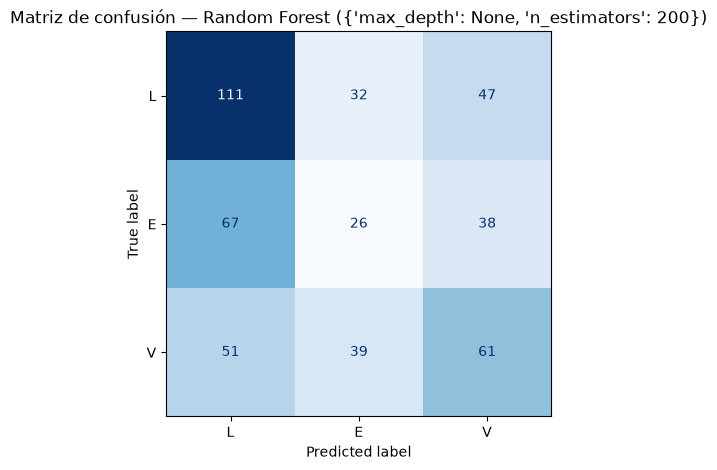

In [7]:
print("Buscando mejores hiperparámetros para Random Forest...")

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid_rf,
    cv=tscv,
    scoring='f1_macro',
    n_jobs=-1,
    return_train_score=True
)

grid_rf.fit(X_train_visible, y_train)

mejores_params_rf = grid_rf.best_params_
print(f"Mejores parámetros para Random Forest: {mejores_params_rf}")

mejor_rf = grid_rf.best_estimator_
preds_rf = mejor_rf.predict(X_test_visible)

metricas_rf = evaluar_modelo(y_test, preds_rf, f"Random Forest ({mejores_params_rf})")
_ = graficar_matriz_confusion(y_test, preds_rf, f"Random Forest ({mejores_params_rf})")
plt.show()

### 5.5 Visualización de Curvas de Error (Bagging Effect)

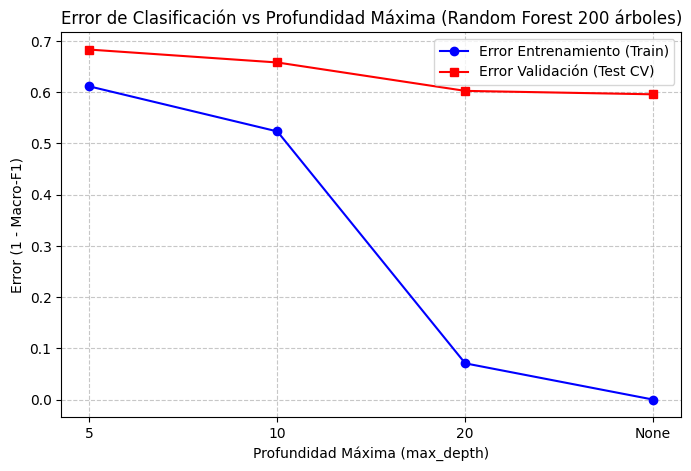

In [34]:
resultados_rf = grid_rf.cv_results_
indices_optimos = [i for i, params in enumerate(resultados_rf['params']) if params['n_estimators'] == 200]
profundidades = [str(resultados_rf['params'][i]['max_depth']) for i in indices_optimos]

error_entrenamiento = 1 - resultados_rf['mean_train_score'][indices_optimos]
error_validacion = 1 - resultados_rf['mean_test_score'][indices_optimos]

plt.figure(figsize=(8, 5))
plt.plot(profundidades, error_entrenamiento, marker='o', label='Error Entrenamiento (Train)', color='blue')
plt.plot(profundidades, error_validacion, marker='s', label='Error Validación (Test CV)', color='red')
plt.title('Error de Clasificación vs Profundidad Máxima (Random Forest 200 árboles)')
plt.xlabel('Profundidad Máxima (max_depth)')
plt.ylabel('Error (1 - Macro-F1)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 6. Clasificadores Naive Bayes (Rol 3)

Se evalúa la clasificación probabilística mediante:
1. **Naive Bayes propio (`NaiveBayesPropio`):** Implementación con suavizado $m$-estimate:
$$P(a_i \mid v_j) = \frac{n_c + m \cdot p}{n + m}$$
y cálculo en espacio logarítmico para evitar el desbordamiento numérico (*underflow*).
2. **Naive Bayes de scikit-learn (`CategoricalNB`):** Uso de `OrdinalEncoder` con un universo fijo de categorías para evitar desajustes en el vocabulario durante `TimeSeriesSplit`.

### 6.1 Naive Bayes Propio

Mejor valor de m encontrado por TimeSeriesSplit: 20.0


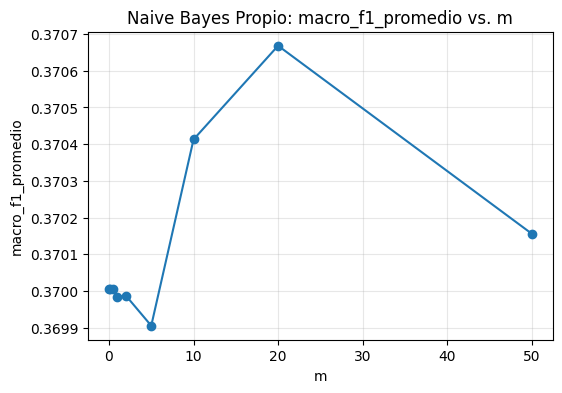

=== Naive Bayes Propio (m=20.0) ===
              precision    recall  f1-score   support

           L      0.460     0.847     0.596       190
           E      0.417     0.038     0.070       131
           V      0.564     0.411     0.475       151

    accuracy                          0.483       472
   macro avg      0.480     0.432     0.380       472
weighted avg      0.481     0.483     0.411       472



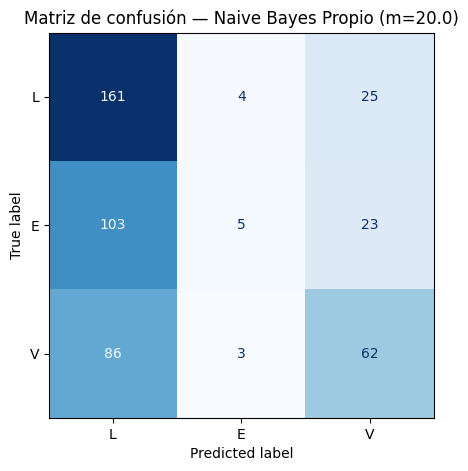

In [35]:
atributos_nb = ['home', 'away']
X_train_nb, y_train_nb = X_train[atributos_nb], y_train
X_test_nb, y_test_nb = X_test[atributos_nb], y_test

def buscar_mejor_m(X_tr_data, y_tr_data, valores_m, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    resultados = []

    for m in valores_m:
        scores = []
        for train_idx, val_idx in tscv.split(X_tr_data):
            X_tr, X_val = X_tr_data.iloc[train_idx], X_tr_data.iloc[val_idx]
            y_tr, y_val = y_tr_data.iloc[train_idx], y_tr_data.iloc[val_idx]

            pipe = Pipeline([('clf', NaiveBayesPropio(m=m))])
            pipe.fit(X_tr, y_tr)
            y_pred = pipe.predict(X_val)

            scores.append(f1_score(y_val, y_pred, labels=CLASES, average='macro'))

        resultados.append({
            'm': m,
            'macro_f1_promedio': np.mean(scores),
            'macro_f1_std': np.std(scores),
        })

    return pd.DataFrame(resultados)

valores_m = [0.01, 0.1, 0.5, 1, 2, 5, 10, 20, 50]
resultados_m = buscar_mejor_m(X_train_nb, y_train_nb, valores_m=valores_m, n_splits=5)
mejor_m = resultados_m.loc[resultados_m['macro_f1_promedio'].idxmax(), 'm']
print(f"Mejor valor de m encontrado por TimeSeriesSplit: {mejor_m}")

fig = graficar_metrica_vs_hiperparametro(resultados_m, 'm', 'macro_f1_promedio', 'Naive Bayes Propio')
plt.show()

pipeline_nb_propio_final = Pipeline([('clf', NaiveBayesPropio(m=mejor_m))])
pipeline_nb_propio_final.fit(X_train_nb, y_train_nb)
preds_nb_propio = pipeline_nb_propio_final.predict(X_test_nb)

metricas_nb_propio = evaluar_modelo(y_test_nb, preds_nb_propio, f"Naive Bayes Propio (m={mejor_m})")
_ = graficar_matriz_confusion(y_test_nb, preds_nb_propio, f"Naive Bayes Propio (m={mejor_m})")
plt.show()

### 6.2 Naive Bayes de scikit-learn (`CategoricalNB`)

Mejor valor de alpha encontrado por TimeSeriesSplit: 1.0


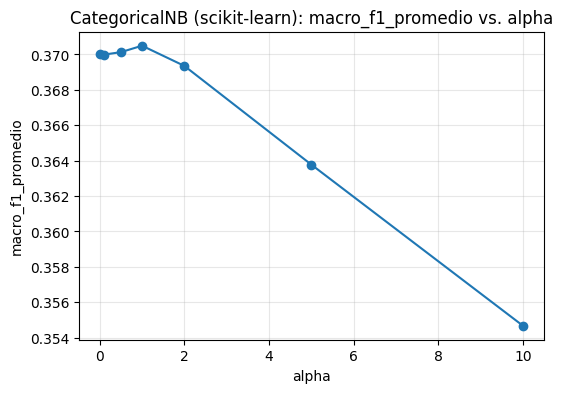

=== CategoricalNB (alpha=1.0) ===
              precision    recall  f1-score   support

           L      0.460     0.847     0.596       190
           E      0.417     0.038     0.070       131
           V      0.564     0.411     0.475       151

    accuracy                          0.483       472
   macro avg      0.480     0.432     0.380       472
weighted avg      0.481     0.483     0.411       472



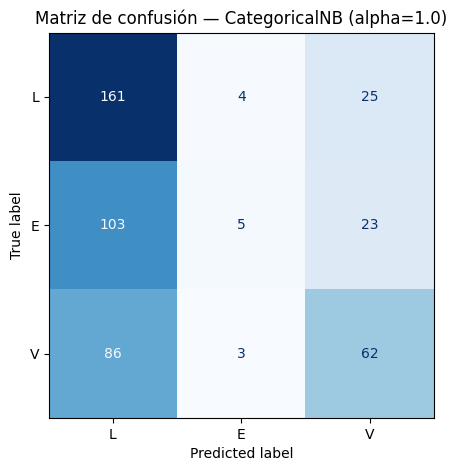

In [36]:
categorias_equipos = [np.sort(X_train_nb['home'].unique()), np.sort(X_train_nb['away'].unique())]
min_categorias = [len(c) for c in categorias_equipos]

def crear_pipeline_nb_sklearn(alpha):
    return Pipeline([
        ('encoder', OrdinalEncoder(
            categories=categorias_equipos,
            handle_unknown='use_encoded_value', unknown_value=-1,
        )),
        ('clf', CategoricalNB(alpha=alpha, min_categories=min_categorias)),
    ])

def buscar_mejor_alpha(X_raw, y, valores_alpha, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    resultados = []

    for alpha in valores_alpha:
        scores = []
        for train_idx, val_idx in tscv.split(X_raw):
            X_tr, X_val = X_raw.iloc[train_idx], X_raw.iloc[val_idx]
            y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

            pipe = crear_pipeline_nb_sklearn(alpha)
            pipe.fit(X_tr, y_tr)
            y_pred = pipe.predict(X_val)

            scores.append(f1_score(y_val, y_pred, labels=CLASES, average='macro'))

        resultados.append({
            'alpha': alpha,
            'macro_f1_promedio': np.mean(scores),
            'macro_f1_std': np.std(scores),
        })

    return pd.DataFrame(resultados)

valores_alpha = [0.01, 0.1, 0.5, 1, 2, 5, 10]
resultados_alpha = buscar_mejor_alpha(X_train_nb, y_train_nb, valores_alpha=valores_alpha)
mejor_alpha = resultados_alpha.loc[resultados_alpha['macro_f1_promedio'].idxmax(), 'alpha']
print(f"Mejor valor de alpha encontrado por TimeSeriesSplit: {mejor_alpha}")

fig = graficar_metrica_vs_hiperparametro(resultados_alpha, 'alpha', 'macro_f1_promedio', 'CategoricalNB (scikit-learn)')
plt.show()

pipeline_nb_sklearn = crear_pipeline_nb_sklearn(mejor_alpha)
pipeline_nb_sklearn.fit(X_train_nb, y_train_nb)
preds_nb_sklearn = pipeline_nb_sklearn.predict(X_test_nb)

metricas_nb_sklearn = evaluar_modelo(y_test_nb, preds_nb_sklearn, f"CategoricalNB (alpha={mejor_alpha})")
_ = graficar_matriz_confusion(y_test_nb, preds_nb_sklearn, f"CategoricalNB (alpha={mejor_alpha})")
plt.show()

### 6.3 Comparación entre NB Propio y `CategoricalNB`

In [37]:
coinciden = (preds_nb_propio == preds_nb_sklearn).all()
n_dif = (preds_nb_propio != preds_nb_sklearn).sum()
print(f"¿Predicciones idénticas en los {len(preds_nb_propio)} partidos de test?: {coinciden}")
print(f"Diferencias registradas: {n_dif} de {len(preds_nb_propio)}")

¿Predicciones idénticas en los 472 partidos de test?: True
Diferencias registradas: 0 de 472


### 6.4 Análisis Cualitativo de Errores en Naive Bayes

In [38]:
analisis_nb = X_test_nb.copy().reset_index(drop=True)
analisis_nb['ganador_real'] = y_test_nb.values
analisis_nb['pred'] = preds_nb_sklearn
analisis_nb['acierto'] = analisis_nb['pred'] == analisis_nb['ganador_real']

print(f"Accuracy Global NB: {analisis_nb['acierto'].mean():.1%}")
print("\nAccuracy por Clase Real:")
display(analisis_nb.groupby('ganador_real')['acierto'].mean().round(3))

print("\nTipos de error más frecuentes (Real -> Predicho):")
errores = analisis_nb[~analisis_nb['acierto']]
display(errores.groupby(['ganador_real', 'pred']).size().sort_values(ascending=False))

Accuracy Global NB: 48.3%

Accuracy por Clase Real:


ganador_real
E    0.038
L    0.847
V    0.411
Name: acierto, dtype: float64


Tipos de error más frecuentes (Real -> Predicho):


ganador_real  pred
E             L       103
V             L        86
L             V        25
E             V        23
L             E         4
V             E         3
dtype: int64

## 7. Comparativa Global de Modelos y Conclusiones Finales

Resumen consolidado del desempeño de todos los modelos evaluados sobre el conjunto de test (2024-2025):

In [39]:
tabla_final = pd.DataFrame([
    {'Modelo': metricas_base['modelo'], 'Accuracy (Test)': metricas_base['accuracy'], 'Macro-F1 (Test)': metricas_base['macro_f1']},
    {'Modelo': metricas_arbol['modelo'], 'Accuracy (Test)': metricas_arbol['accuracy'], 'Macro-F1 (Test)': metricas_arbol['macro_f1']},
    {'Modelo': metricas_rf['modelo'], 'Accuracy (Test)': metricas_rf['accuracy'], 'Macro-F1 (Test)': metricas_rf['macro_f1']},
    {'Modelo': metricas_nb_propio['modelo'], 'Accuracy (Test)': metricas_nb_propio['accuracy'], 'Macro-F1 (Test)': metricas_nb_propio['macro_f1']},
    {'Modelo': metricas_nb_sklearn['modelo'], 'Accuracy (Test)': metricas_nb_sklearn['accuracy'], 'Macro-F1 (Test)': metricas_nb_sklearn['macro_f1']},
])

display(tabla_final.sort_values(by='Macro-F1 (Test)', ascending=False).reset_index(drop=True))

,Modelo,Accuracy (Test),Macro-F1 (Test)
0,"Random Forest ({'max_depth': None, 'n_estimato...",0.419492,0.389559
1,CategoricalNB (alpha=1.0),0.483051,0.380441
2,Naive Bayes Propio (m=20.0),0.483051,0.380441
3,Clasificador Base (10 Años),0.461864,0.361594
4,Árbol Propio (min_info_gain=0.0),0.347458,0.340955


### **Conclusiones Generales:**
1. **Ventaja del Bagging:** `RandomForestClassifier` logra el mejor desempeño (Macro-F1 ≈ 0.390, Accuracy ≈ 0.420), superando al árbol único al promediar la varianza de múltiples árboles.
2. **Sobreajuste Estructural del Árbol Único:** El árbol de decisión propio sufre sobreajuste debido a la falta de restricciones en la profundidad máxima y tamaño de hojas, memorizando el entrenamiento (Accuracy train ~0.999) pero decayendo en test (Macro-F1 ≈ 0.341).
3. **Consistencia de Naive Bayes:** La implementación propia con $m$-estimate replica con precisión las predicciones de `CategoricalNB` de scikit-learn.
4. **Dificultad de los Empates:** Todos los modelos muestran tendencia a sobre-predecir victorias locales ('L') y sufren para predecir empates ('E').
5. **Trabajo Futuro:** Incorporar características relativas directas (diferencia de forma `home_form - away_form`, enfrentamientos directos *head-to-head*) para mejorar el reconocimiento de partidos parejos.

## 8. Clasificación de Instancias Específicas (Demostración Práctica)

En cumplimiento con el **Entregable 2** de la consigna (*"Jupyter Notebook que lea el conjunto de datos, entrene los modelos y muestre su funcionamiento clasificando instancias"*), a continuación se implementa una función interactiva para seleccionar partidos específicos del conjunto de evaluación (2024-2025) y comparar la predicción y las probables clases otorgadas por cada uno de los clasificadores entrenados.


In [ ]:
def clasificar_instancias_partidos(indices_partidos, X_raw_test, y_raw_test, X_proc_test):
    """
    Muestra un reporte detallado con las predicciones de todos los modelos entrenados
    para una lista de índices de partidos del conjunto de evaluación.
    """
    filas_reporte = []
    
    for idx in indices_partidos:
        row_raw = X_raw_test.iloc[idx]
        val_real = y_raw_test.iloc[idx]
        row_proc = X_proc_test.iloc[[idx]]
        df_single_raw = X_raw_test.iloc[[idx]]
        
        # Datos raw para el baseline
        pred_base = clf_base.predict(df_single_raw)[0]
        
        # Datos procesados para árbol propio y Random Forest
        pred_arbol = arbol_mejor.predict(row_proc)[0]
        pred_rf = mejor_rf.predict(row_proc)[0]
        
        # Datos categóricos ('home', 'away') para los clasificadores Naive Bayes
        row_nb = df_single_raw[['home', 'away']]
        pred_nb_propio = pipeline_nb_propio_final.predict(row_nb)[0]
        pred_nb_sk = pipeline_nb_sklearn.predict(row_nb)[0]
        
        # Obtener probas de NB Propio como ejemplo demostrativo de proba por clase
        probas_nb = pipeline_nb_propio_final.predict_proba(row_nb).round(3).to_dict(orient='records')[0]
        
        # Manejo flexible del nombre de columnas de forma
        home_form_col = 'remainder__home_form' if 'remainder__home_form' in row_proc.columns else 'home_form'
        away_form_col = 'remainder__away_form' if 'remainder__away_form' in row_proc.columns else 'away_form'
        
        filas_reporte.append({
            'Índice': idx,
            'Fecha': row_raw['date'].strftime('%Y-%m-%d'),
            'Partido': f"{row_raw['home']} vs {row_raw['away']}",
            'Forma Local / Visitante': f"{row_proc[home_form_col].values[0]:.2f} / {row_proc[away_form_col].values[0]:.2f}",
            'Real': val_real,
            'Base (10 Años)': pred_base,
            'Árbol Custom': pred_arbol,
            'Random Forest': pred_rf,
            'NB Custom': pred_nb_propio,
            'CategoricalNB': pred_nb_sk,
            'Probas NB (L, E, V)': f"L:{probas_nb.get('L', 0):.2f}, E:{probas_nb.get('E', 0):.2f}, V:{probas_nb.get('V', 0):.2f}"
        })
    
    df_res = pd.DataFrame(filas_reporte)
    return df_res

# ==============================================================================
# OPCIONES PARA SELECCIONAR OTRAS PARTIDAS (Cualquier partido de 2024-2025)
# ==============================================================================

# Opcion 1: Muestra variada representativa (Clásicos + Victoria Local + Empate + Victoria Visitante)
idx_clasico = np.where((X_test['home'].str.contains('Penarol|Nacional')) & (X_test['away'].str.contains('Penarol|Nacional')))[0]
idx_local = np.where(y_test == 'L')[0][:1]
idx_empate = np.where(y_test == 'E')[0][:1]
idx_visita = np.where(y_test == 'V')[0][:1]

indices_demo = list(set(idx_clasico[:2].tolist() + idx_local.tolist() + idx_empate.tolist() + idx_visita.tolist()))
indices_demo.sort()

# Opcion 2 (Descomentar para filtrar por un equipo especifico, ej. 'Danubio'):
# mask_equipo = (X_test['home'].str.contains('Danubio')) | (X_test['away'].str.contains('Danubio'))
# indices_demo = np.where(mask_equipo)[0][:5].tolist()

# Opcion 3 (Descomentar para elegir índices específicos manualmente):
# indices_demo = [0, 15, 30, 45, 100]

print("=== Demostración de Clasificación de Instancias (Entregable 2) ===")
tabla_instancias = clasificar_instancias_partidos(indices_demo, X_test.reset_index(drop=True), y_test.reset_index(drop=True), X_test_visible.reset_index(drop=True))
display(tabla_instancias)
